In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
pd.options.display.max_columns=None
import warnings


In [2]:
df = pd.read_csv('/kaggle/input/marvel-vs-dc/Marvel Vs DC NEW.csv')
df.head()

,ID,Movie,Year,Genre,RunTime,Description,IMDB_Score
0,0,Eternals,-2021,"Action,Adventure,Drama",0,"The saga of the Eternals, a race of immortal b...",0.0
1,1,Loki,(2021– ),"Action,Adventure,Fantasy",0,A new Marvel chapter with Loki at its center.,0.0
2,2,The Falcon and the Winter Soldier,-2021,"Action,Adventure,Drama",50 min,"Following the events of 'Avengers: Endgame,' S...",7.5
3,3,WandaVision,-2021,"Action,Comedy,Drama",350 min,Blends the style of classic sitcoms with the M...,8.1
4,4,Spider-Man: No Way Home,-2021,"Action,Adventure,Sci-Fi",0,A continuation of Spider-Man: Far From Home.,0.0


In [3]:
def longest_zero_sequence(binary_list):
    max_zeros = 0
    current_zeros = 0
    
    for num in binary_list:
        if num ==0:
            current_zeros +=1
        else:
            max_zeros = max(max_zeros,current_zeros)
            current_zeros = 0
    max_zeros = max(max_zeros,current_zeros)
    return max_zeros
binary_list = [1,0,0,0,1,1,0,0,1]
print(longest_zero_sequence(binary_list))

3


In [4]:
def even_index_elements(arr):
    return arr[::2]
arr = np.array([10,20,30,40,50,60,70,80,90,100])
result = even_index_elements(arr)
print(result)

[10 30 50 70 90]


In [5]:
df.head()

,ID,Movie,Year,Genre,RunTime,Description,IMDB_Score
0,0,Eternals,-2021,"Action,Adventure,Drama",0,"The saga of the Eternals, a race of immortal b...",0.0
1,1,Loki,(2021– ),"Action,Adventure,Fantasy",0,A new Marvel chapter with Loki at its center.,0.0
2,2,The Falcon and the Winter Soldier,-2021,"Action,Adventure,Drama",50 min,"Following the events of 'Avengers: Endgame,' S...",7.5
3,3,WandaVision,-2021,"Action,Comedy,Drama",350 min,Blends the style of classic sitcoms with the M...,8.1
4,4,Spider-Man: No Way Home,-2021,"Action,Adventure,Sci-Fi",0,A continuation of Spider-Man: Far From Home.,0.0


In [6]:
df = pd.read_csv('/kaggle/input/marvel-vs-dc/Marvel Vs DC NEW.csv')
df.head()

,ID,Movie,Year,Genre,RunTime,Description,IMDB_Score
0,0,Eternals,-2021,"Action,Adventure,Drama",0,"The saga of the Eternals, a race of immortal b...",0.0
1,1,Loki,(2021– ),"Action,Adventure,Fantasy",0,A new Marvel chapter with Loki at its center.,0.0
2,2,The Falcon and the Winter Soldier,-2021,"Action,Adventure,Drama",50 min,"Following the events of 'Avengers: Endgame,' S...",7.5
3,3,WandaVision,-2021,"Action,Comedy,Drama",350 min,Blends the style of classic sitcoms with the M...,8.1
4,4,Spider-Man: No Way Home,-2021,"Action,Adventure,Sci-Fi",0,A continuation of Spider-Man: Far From Home.,0.0


In [7]:
num_rows = df.shape[0]
print(f"Number of rows: {num_rows}")

num_columns = df.shape[1]
print(f"Number of columns: {num_columns}")

data_types = df.dtypes
print("\ndata types of variables:")
print(data_types)

continuous_vars = data_types[data_types.apply(lambda x:pd.api.types.is_numeric_dtype(x))]
categorical_vars = data_types[data_types.apply(lambda x: pd.api.types.is_categorical_dtype(x) or pd.api.types.is_object_dtype(x))]

print("\nNumber of continuous variables:", len(continuous_vars))
print("Continuous variables:", continuous_vars.index.tolist())

print("\nNumber of categorical variables:",len(categorical_vars))
print("Categorical variables:", categorical_vars.index.tolist())

Number of rows: 1690
Number of columns: 7

data types of variables:
ID               int64
Movie           object
Year            object
Genre           object
RunTime         object
Description     object
IMDB_Score     float64
dtype: object

Number of continuous variables: 2
Continuous variables: ['ID', 'IMDB_Score']

Number of categorical variables: 5
Categorical variables: ['Movie', 'Year', 'Genre', 'RunTime', 'Description']


/tmp/ipykernel_30/2368518680.py:12: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  categorical_vars = data_types[data_types.apply(lambda x: pd.api.types.is_categorical_dtype(x) or pd.api.types.is_object_dtype(x))]


In [8]:
fiv_point_summary = df.describe(percentiles=[0.25,0.5,0.75])
print("five point summary:")
print(fiv_point_summary.loc[['min','25%','50%','75%','max']])

five point summary:
          ID  IMDB_Score
min     0.00         0.0
25%   422.25         6.9
50%   844.50         7.8
75%  1266.75         8.4
max  1689.00         9.6


In [9]:
statistical_summary = df.describe()
print("Statistical summary for numerical variables:")
print(statistical_summary)

Statistical summary for numerical variables:
                ID   IMDB_Score
count  1690.000000  1690.000000
mean    844.500000     6.877337
std     488.005294     2.690564
min       0.000000     0.000000
25%     422.250000     6.900000
50%     844.500000     7.800000
75%    1266.750000     8.400000
max    1689.000000     9.600000


In [51]:
df_copy = df.copy()

columns_to_remove = ['Year','RunTime','IMDB_Score']
df_copy.drop(columns=columns_to_remove,inplace=True,errors='ignore')

print("New dataframe after removing specified columns:")
print(df_copy.head())

missing_values = df_copy.isnull().sum()
print("\nMissing values in each columns:")
print(missing_values)

duplicates = df_copy.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")

df_copy.fillna(df_copy,inplace=True)

df_copy.drop_duplicates(inplace=True)
print("\nCleaned Dataframe:")
print(df_copy.head())

New dataframe after removing specified columns:
   ID                              Movie                     Genre  \
0   0                           Eternals    Action,Adventure,Drama   
1   1                               Loki  Action,Adventure,Fantasy   
2   2  The Falcon and the Winter Soldier    Action,Adventure,Drama   
3   3                        WandaVision       Action,Comedy,Drama   
4   4            Spider-Man: No Way Home   Action,Adventure,Sci-Fi   

                                         Description  
0  The saga of the Eternals, a race of immortal b...  
1      A new Marvel chapter with Loki at its center.  
2  Following the events of 'Avengers: Endgame,' S...  
3  Blends the style of classic sitcoms with the M...  
4       A continuation of Spider-Man: Far From Home.  

Missing values in each columns:
ID             0
Movie          0
Genre          7
Description    0
dtype: int64

Number of duplicate rows: 0

Cleaned Dataframe:
   ID                              Mov

In [11]:
df.head()

,ID,Movie,Year,Genre,RunTime,Description,IMDB_Score
0,0,Eternals,-2021,"Action,Adventure,Drama",0,"The saga of the Eternals, a race of immortal b...",0.0
1,1,Loki,(2021– ),"Action,Adventure,Fantasy",0,A new Marvel chapter with Loki at its center.,0.0
2,2,The Falcon and the Winter Soldier,-2021,"Action,Adventure,Drama",50 min,"Following the events of 'Avengers: Endgame,' S...",7.5
3,3,WandaVision,-2021,"Action,Comedy,Drama",350 min,Blends the style of classic sitcoms with the M...,8.1
4,4,Spider-Man: No Way Home,-2021,"Action,Adventure,Sci-Fi",0,A continuation of Spider-Man: Far From Home.,0.0


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1690 entries, 0 to 1689
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   ID           1690 non-null   int64  
 1   Movie        1690 non-null   object 
 2   Year         1657 non-null   object 
 3   Genre        1683 non-null   object 
 4   RunTime      1690 non-null   object 
 5   Description  1690 non-null   object 
 6   IMDB_Score   1690 non-null   float64
dtypes: float64(1), int64(1), object(5)
memory usage: 92.5+ KB


In [14]:
df.dtypes

ID               int64
Movie           object
Year            object
Genre           object
RunTime         object
Description     object
IMDB_Score     float64
dtype: object

In [15]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
ID,1690.0,844.500000,488.005294,0.0,422.25,844.5,1266.75,1689.0
IMDB_Score,1690.0,6.877337,2.690564,0.0,6.90,7.8,8.40,9.6


In [21]:
df.isnull().notnull()/len(df*50)

,ID,Movie,Year,Genre,RunTime,Description,IMDB_Score
0,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
1,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
2,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
3,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
4,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
...,...,...,...,...,...,...,...
1685,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
1686,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
1687,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592
1688,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592,0.000592


In [22]:
df.shape

(1690, 7)

<Axes: >

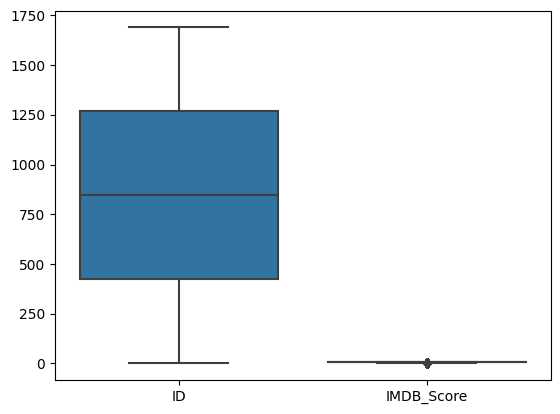

In [24]:
sns.boxplot(df)

<Axes: >

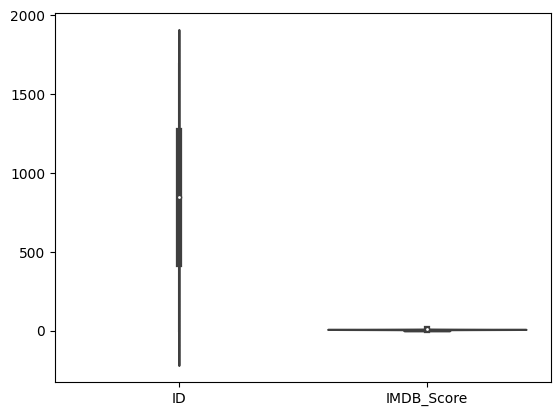

In [25]:
sns.violinplot(df)

<Axes: >

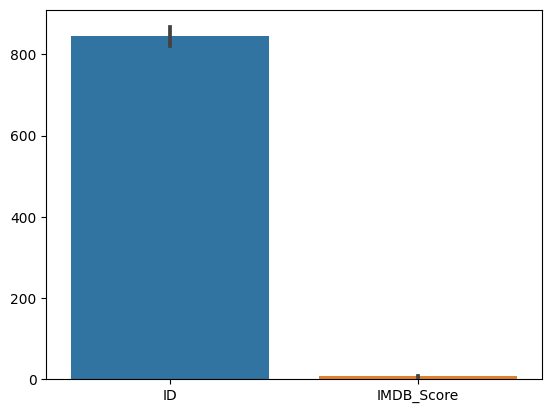

In [26]:
sns.barplot(df)

<Axes: >

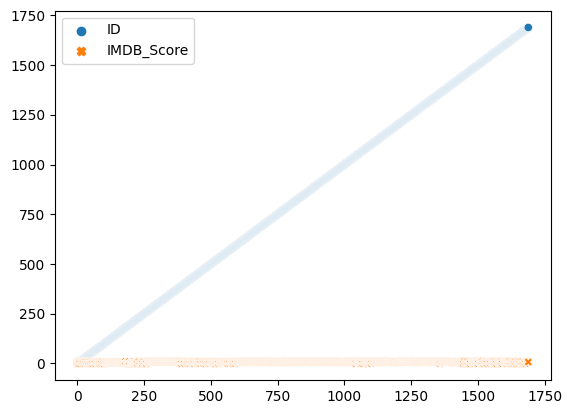

In [27]:
sns.scatterplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: >

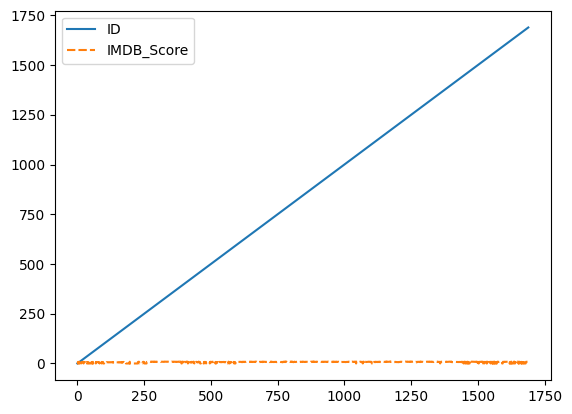

In [28]:
sns.lineplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

<Axes: ylabel='Density'>

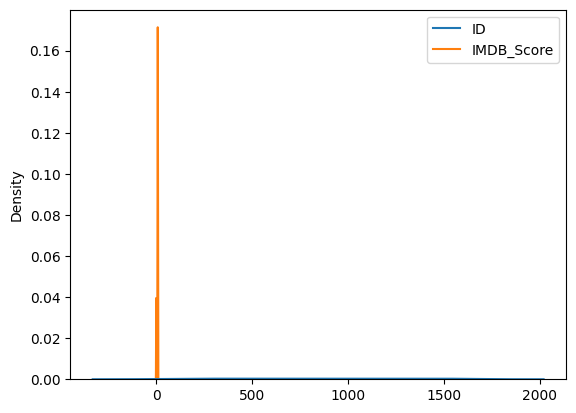

In [29]:
sns.kdeplot(df)

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


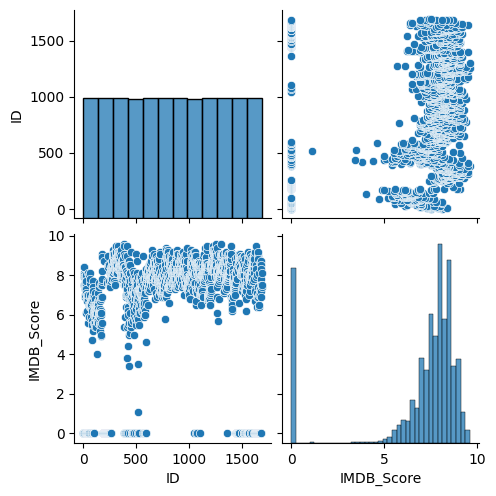

In [30]:
sns.pairplot(df)

In [32]:
df.skew

<bound method DataFrame.skew of         ID                              Movie         Year  \
0        0                           Eternals        -2021   
1        1                               Loki     (2021– )   
2        2  The Falcon and the Winter Soldier        -2021   
3        3                        WandaVision        -2021   
4        4            Spider-Man: No Way Home        -2021   
...    ...                                ...          ...   
1685  1685           DC's Legends of Tomorrow     (2016– )   
1686  1686                          Supergirl  (2015–2021)   
1687  1687                          Supergirl  (2015–2021)   
1688  1688                          Supergirl  (2015–2021)   
1689  1689                          Supergirl  (2015–2021)   

                         Genre  RunTime  \
0       Action,Adventure,Drama        0   
1     Action,Adventure,Fantasy        0   
2       Action,Adventure,Drama   50 min   
3          Action,Comedy,Drama  350 min   
4      A

In [33]:
df.kurt

<bound method DataFrame.kurt of         ID                              Movie         Year  \
0        0                           Eternals        -2021   
1        1                               Loki     (2021– )   
2        2  The Falcon and the Winter Soldier        -2021   
3        3                        WandaVision        -2021   
4        4            Spider-Man: No Way Home        -2021   
...    ...                                ...          ...   
1685  1685           DC's Legends of Tomorrow     (2016– )   
1686  1686                          Supergirl  (2015–2021)   
1687  1687                          Supergirl  (2015–2021)   
1688  1688                          Supergirl  (2015–2021)   
1689  1689                          Supergirl  (2015–2021)   

                         Genre  RunTime  \
0       Action,Adventure,Drama        0   
1     Action,Adventure,Fantasy        0   
2       Action,Adventure,Drama   50 min   
3          Action,Comedy,Drama  350 min   
4      A

In [36]:
df.corr

<bound method DataFrame.corr of         ID                              Movie         Year  \
0        0                           Eternals        -2021   
1        1                               Loki     (2021– )   
2        2  The Falcon and the Winter Soldier        -2021   
3        3                        WandaVision        -2021   
4        4            Spider-Man: No Way Home        -2021   
...    ...                                ...          ...   
1685  1685           DC's Legends of Tomorrow     (2016– )   
1686  1686                          Supergirl  (2015–2021)   
1687  1687                          Supergirl  (2015–2021)   
1688  1688                          Supergirl  (2015–2021)   
1689  1689                          Supergirl  (2015–2021)   

                         Genre  RunTime  \
0       Action,Adventure,Drama        0   
1     Action,Adventure,Fantasy        0   
2       Action,Adventure,Drama   50 min   
3          Action,Comedy,Drama  350 min   
4      A

In [37]:
cat_cols = df.select_dtypes(include='object')

In [38]:
for i in cat_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

Movie



Year



Genre



RunTime



Description





In [40]:
num_cols = df.select_dtypes(include='number')

In [41]:
for i in num_cols:
    print(i)
    (df[i].value_counts())
    print('\n')
    print(''*50)

ID



IMDB_Score





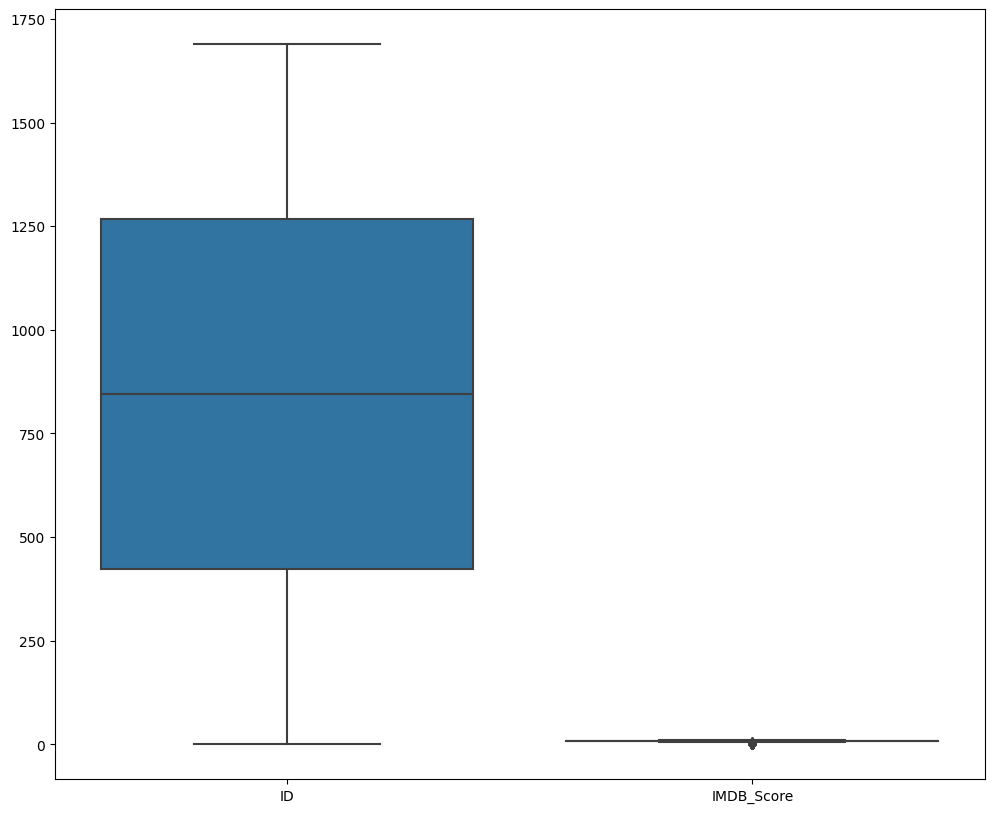

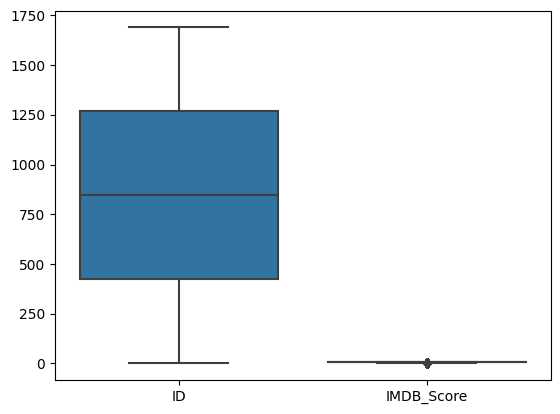

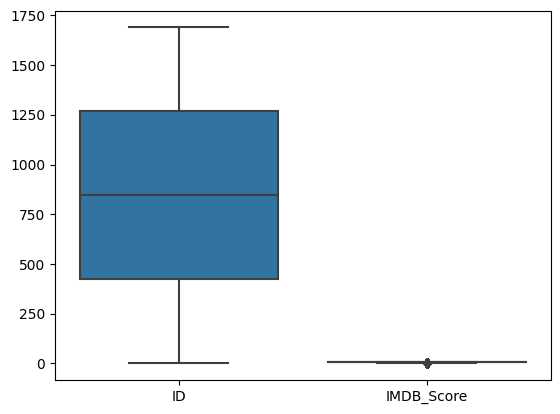

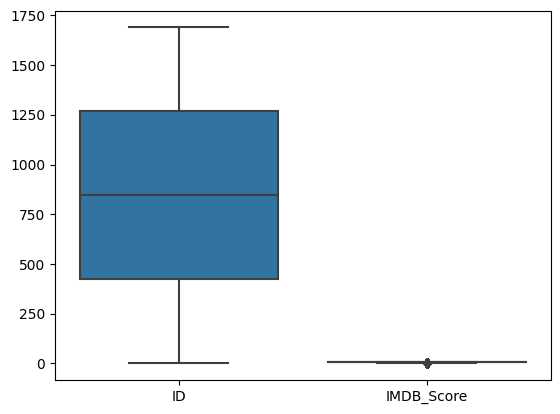

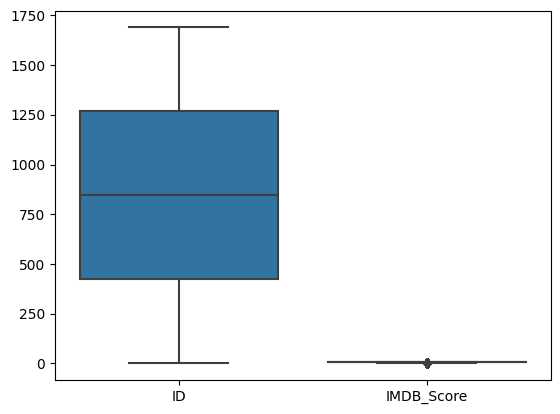

In [43]:
x = 1
plt.figure(figsize=(12,10))
cat_cols = df.select_dtypes(include='object')
for i in cat_cols:
    sns.boxplot(data=df)
    print('\n')
    plt.show()

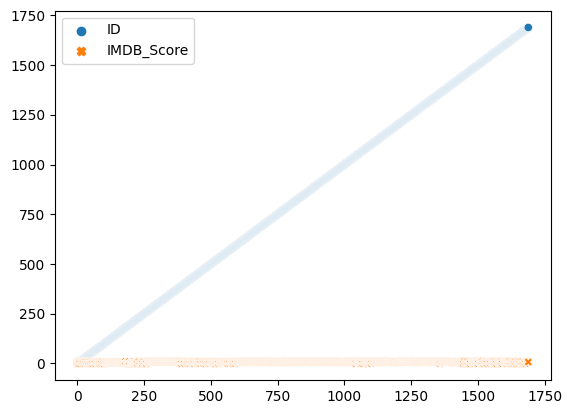

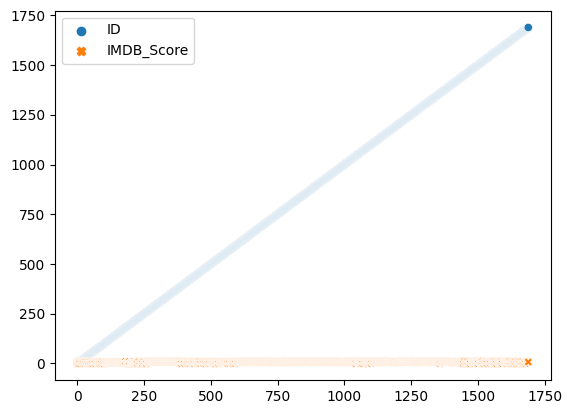

In [44]:
x = 1
num_cols = df.select_dtypes(include='number')
for i in num_cols:
    sns.scatterplot(data=df)
    print('\n')
    plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-l

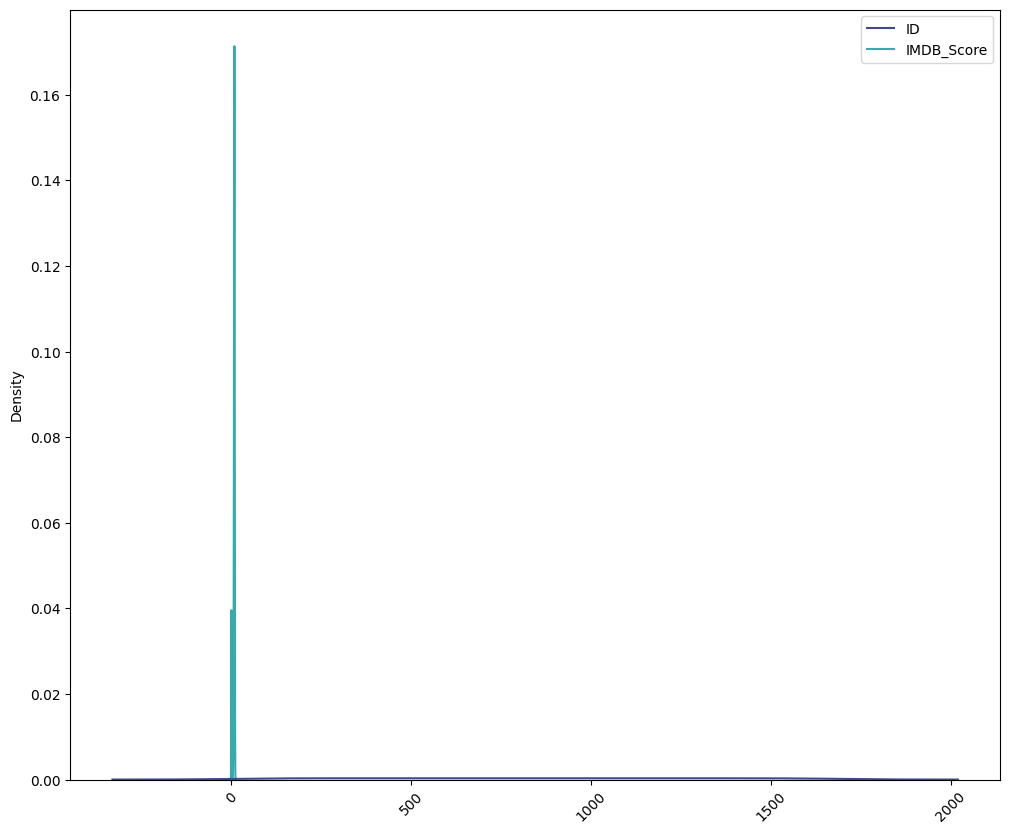

In [46]:
plt.figure(figsize=(12,10))
sns.kdeplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


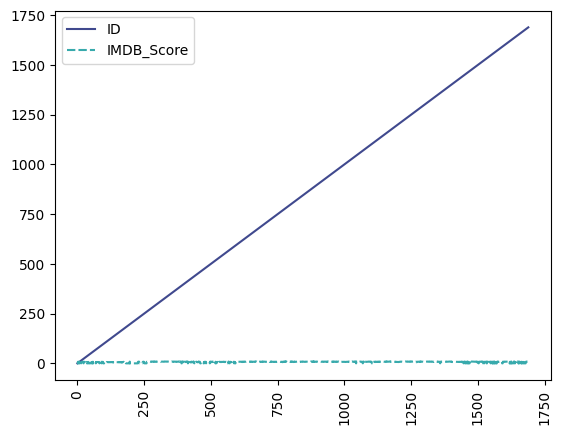

In [49]:
sns.lineplot(data=df,palette='mako');
plt.xticks(rotation=90)
plt.show()

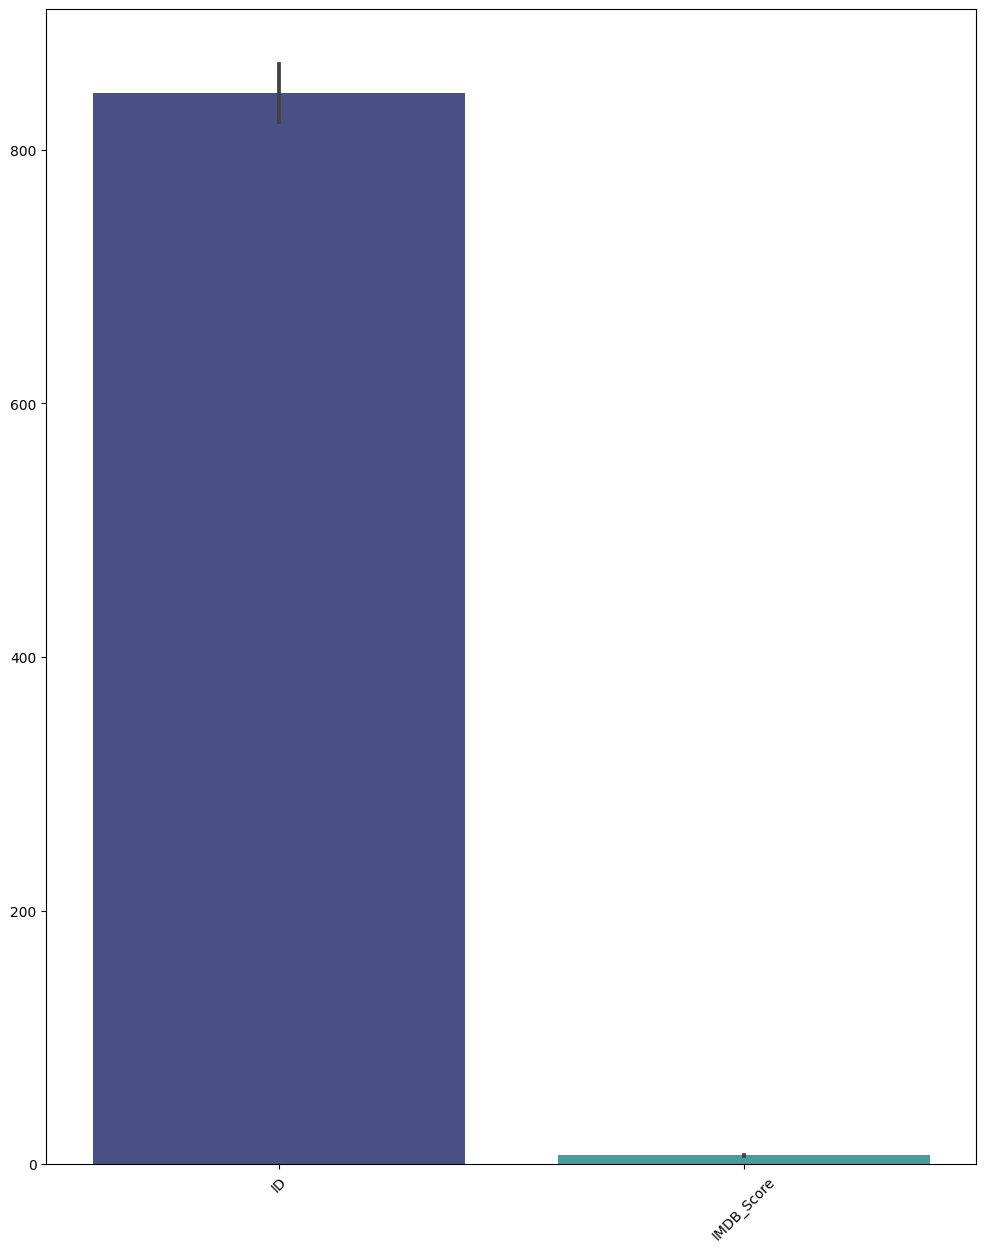

In [50]:
plt.figure(figsize=(12,15))
sns.barplot(data=df,palette='mako');
plt.xticks(rotation=45);
plt.show()

In [57]:
import plotly.express as px
import plotly.graph_objects as go
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore')

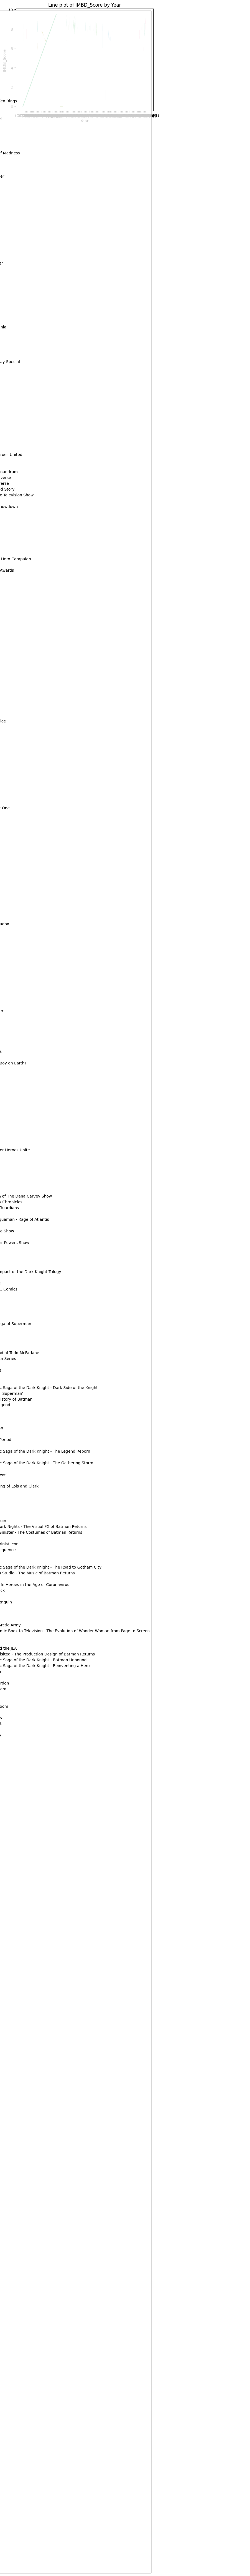

In [61]:
sns.lineplot(x='Year', y='IMDB_Score',data=df, hue='Movie', style='RunTime')
plt.title("Line plot of IMBD_Score by Year")
plt.show()

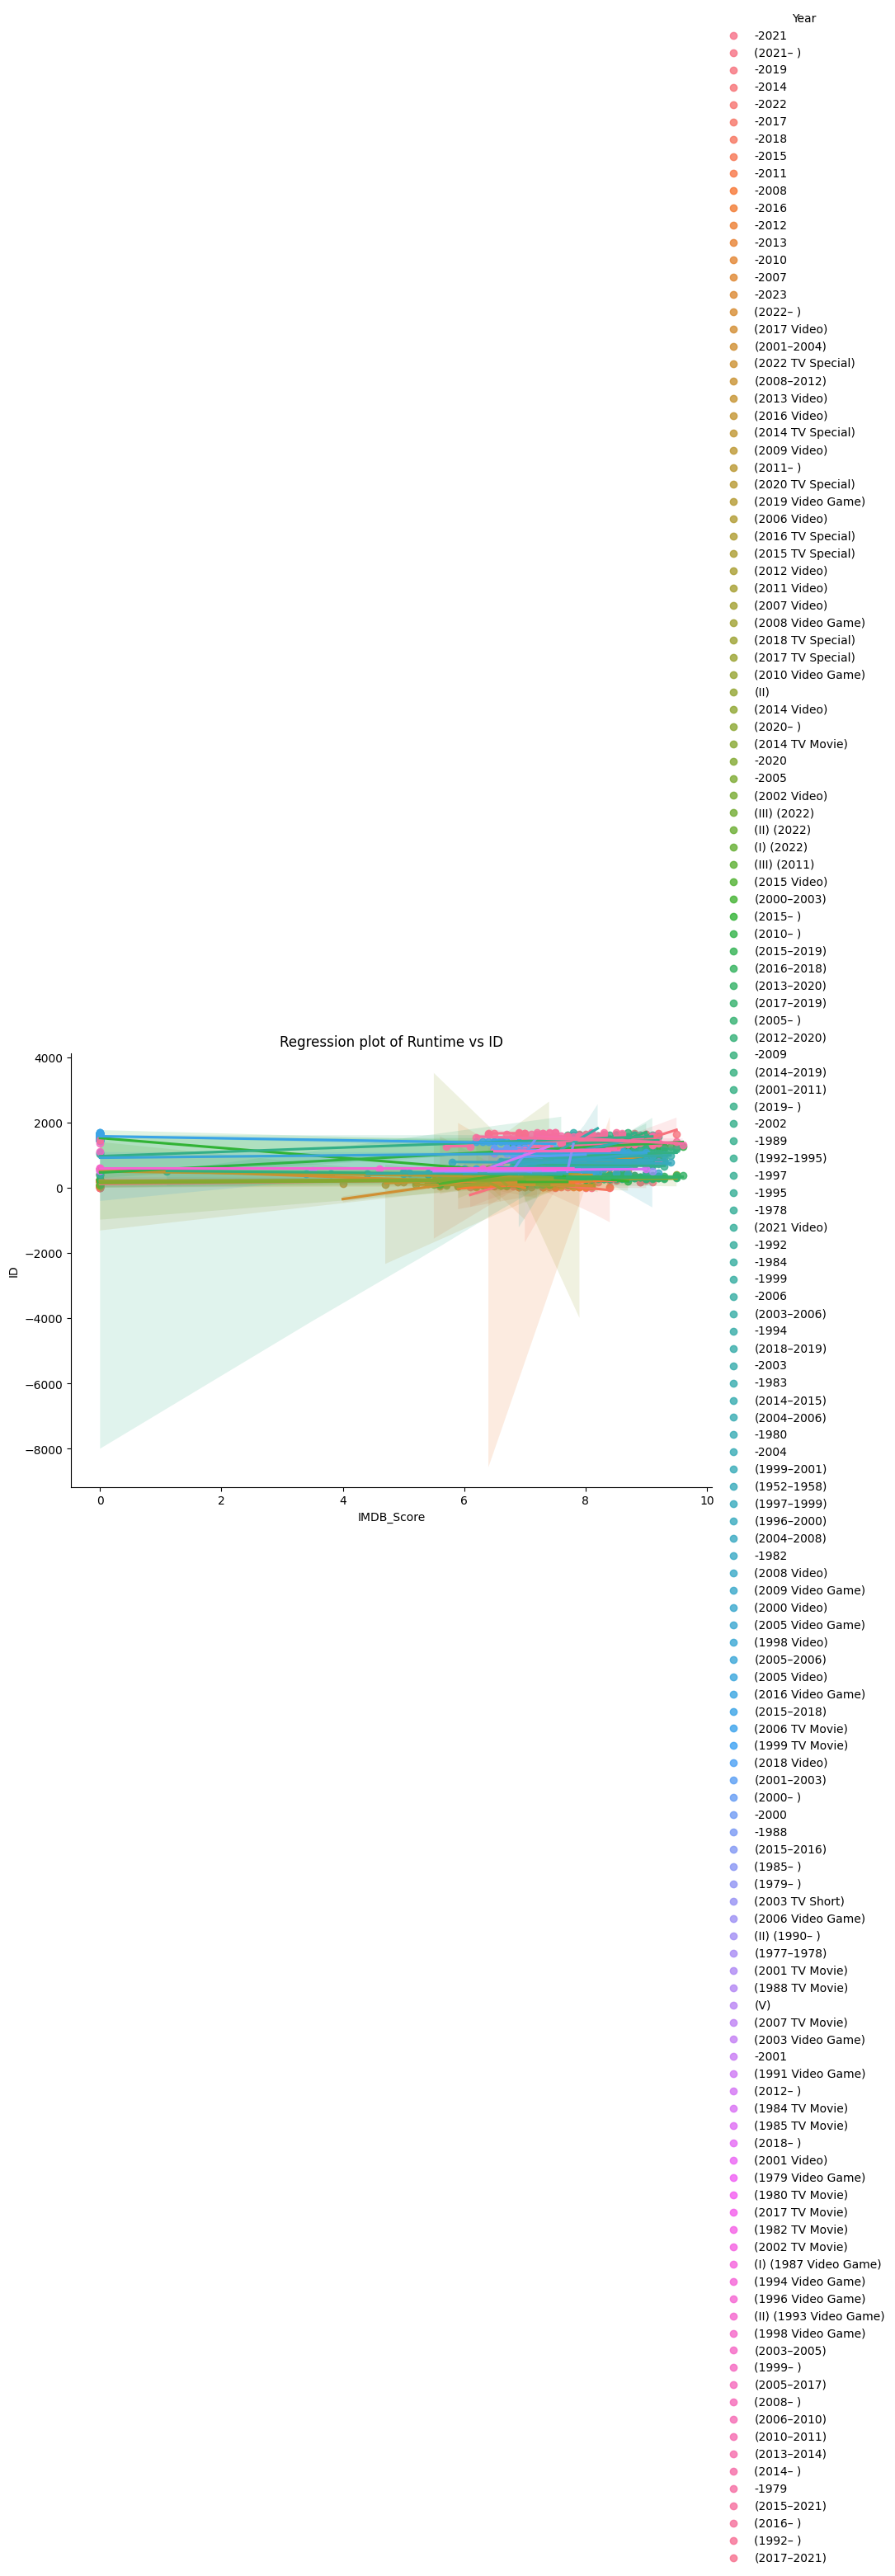

In [65]:
sns.lmplot(x='IMDB_Score', y='ID', data=df, hue='Year', height=6, aspect=1.5)
plt.title("Regression plot of Runtime vs ID")
plt.show()

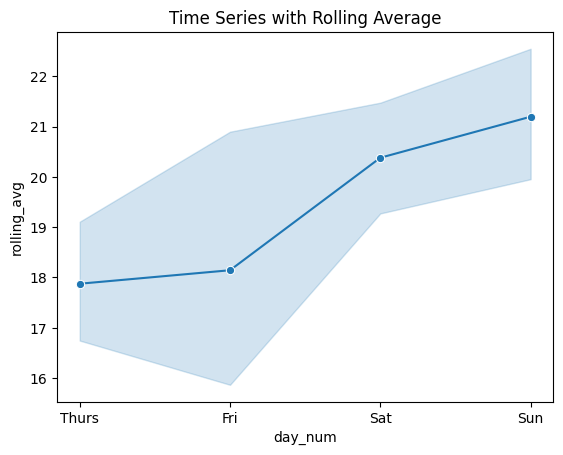

In [67]:
df_tips = sns.load_dataset("tips")
df_tips['day_num'] = df_tips['day'].astype('category').cat.codes

df_tips['rolling_avg'] = df_tips['total_bill'].rolling(window=3).mean()

sns.lineplot(x='day_num', y='rolling_avg', data=df_tips,marker='o')
plt.xticks(ticks=[0,1,2,3],  labels=["Thurs","Fri","Sat","Sun"])
plt.title("Time Series with Rolling Average")
plt.show()